# Experiment 005 — Hyperparameter Tuning (CatBoost)

**Goal:** Tune CatBoost (exp_004 winner) using a two-stage search strategy:
1. **RandomizedSearchCV** — broad search over a wide parameter space to find the best region
2. **GridSearchCV** — narrow search around the best values from stage 1

**Baseline to beat (exp_004 CatBoost defaults):**
- CV AUC: 0.8909 | Hold-out AUC: 0.8506 | F1 (Survived): 0.783 | Recall (Survived): 0.812

**Feature set:** exp_003 (same throughout)
**Imbalance method:** Random Undersampling inside CV folds (ImbPipeline)
**Scoring:** F1 (Survived) — consistent with exp_002 onwards

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, GridSearchCV
)
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay, make_scorer, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
%matplotlib inline

f1_survived = make_scorer(f1_score, pos_label=1)

## 2. Load, Preprocess & Feature Engineering (identical to exp_003/004)

In [2]:
df = pd.read_csv('../../data/raw/train.csv')
df = df.drop(columns=['PassengerId'])

df['Name_title'] = df['Name'].str.extract(r',\s*([^.]+)\.')
df['Cabin_deck'] = df['Cabin'].str[0]
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.copy()
X_test  = X_test.copy()

# Impute
age_median    = X_train['Age'].median()
embarked_mode = X_train['Embarked'].mode()[0]
for df_ in [X_train, X_test]:
    df_['Age']        = df_['Age'].fillna(age_median)
    df_['Embarked']   = df_['Embarked'].fillna(embarked_mode)
    df_['Cabin_deck'] = df_['Cabin_deck'].fillna('Unknown')

# Title grouping
title_map     = {'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss'}
common_titles = {'Mr', 'Mrs', 'Miss', 'Master'}
for df_ in [X_train, X_test]:
    df_['Name_title'] = df_['Name_title'].replace(title_map)
    df_['Name_title'] = df_['Name_title'].apply(lambda t: t if t in common_titles else 'Rare')

# Feature engineering
for df_ in [X_train, X_test]:
    df_['FamilySize']    = df_['SibSp'] + df_['Parch'] + 1
    df_['IsAlone']       = (df_['FamilySize'] == 1).astype(int)
    df_['LogFare']       = np.log1p(df_['Fare'])
    df_['AgeGroup']      = pd.cut(df_['Age'], bins=[0, 16, 60, np.inf], labels=['Child', 'Adult', 'Senior'])
    df_['Pclass_x_Fare'] = df_['Pclass'] * df_['Fare']
    df_['FarePerPerson'] = df_['Fare'] / df_['FamilySize']

# Encode
encode_cols = ['Sex', 'Embarked', 'Name_title', 'Cabin_deck', 'AgeGroup']
X_train = pd.get_dummies(X_train, columns=encode_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=encode_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Scale
num_scale_cols = ['Age', 'Fare', 'FamilySize', 'LogFare', 'Pclass_x_Fare', 'FarePerPerson']
scaler = StandardScaler()
X_train[num_scale_cols] = scaler.fit_transform(X_train[num_scale_cols])
X_test[num_scale_cols]  = scaler.transform(X_test[num_scale_cols])

print(f'Features: {X_train.shape[1]} | Nulls: {X_train.isnull().sum().sum()}')

Features: 27 | Nulls: 0


## 3. Stage 1 — RandomizedSearchCV (broad search)

In [3]:
# Wide parameter space — let the random search explore broadly
# iterations: number of boosting rounds (more = better but slower)
# depth: tree depth (CatBoost default is 6; deeper = more complex)
# learning_rate: step size (lower = more robust, needs more iterations)
# l2_leaf_reg: L2 regularisation on leaf values (higher = more regularised)
# border_count: number of splits for numerical features (higher = finer)
param_dist = {
    'clf__iterations':    [100, 200, 300, 500],
    'clf__depth':         [3, 4, 5, 6, 7, 8],
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'clf__l2_leaf_reg':   [1, 3, 5, 7, 10],
    'clf__border_count':  [32, 64, 128],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_pipe = ImbPipeline([
    ('sampler', RandomUnderSampler(random_state=42)),
    ('clf',     CatBoostClassifier(random_state=42, verbose=0)),
])

random_search = RandomizedSearchCV(
    random_pipe,
    param_distributions=param_dist,
    n_iter=50,           # test 50 random combinations
    scoring=f1_survived,
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train, y_train)

print(f'\nBest CV F1 (Survived): {random_search.best_score_:.4f}')
print(f'Best params: {random_search.best_params_}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV F1 (Survived): 0.7902
Best params: {'clf__learning_rate': 0.05, 'clf__l2_leaf_reg': 10, 'clf__iterations': 200, 'clf__depth': 5, 'clf__border_count': 32}


In [4]:
# Evaluate best random search model on hold-out set
best_random = random_search.best_estimator_
y_pred_r = best_random.predict(X_test)
y_prob_r = best_random.predict_proba(X_test)[:, 1]

print('--- Stage 1 (RandomizedSearch) hold-out results ---')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_r):.4f}')
print()
print(classification_report(y_test, y_pred_r, target_names=['Not Survived', 'Survived']))

--- Stage 1 (RandomizedSearch) hold-out results ---
ROC-AUC: 0.8414

              precision    recall  f1-score   support

Not Survived       0.86      0.80      0.83       110
    Survived       0.71      0.80      0.75        69

    accuracy                           0.80       179
   macro avg       0.79      0.80      0.79       179
weighted avg       0.81      0.80      0.80       179



## 4. Stage 2 — GridSearchCV (narrow search around best params)

In [5]:
# Extract best params from stage 1 and build a narrow grid around them
bp = random_search.best_params_
print('Stage 1 best params (building grid around these):')
for k, v in bp.items():
    print(f'  {k}: {v}')

def neighbour_int(val, step, low, high):
    """Return [val-step, val, val+step] clipped to [low, high], deduplicated."""
    return sorted(set(max(low, min(high, val + d)) for d in [-step, 0, step]))

def neighbour_float(val, options):
    """Return the 3 closest values in options to val."""
    return sorted(options, key=lambda x: abs(x - val))[:3]

param_grid = {
    'clf__iterations':    neighbour_int(bp['clf__iterations'],    100, 100, 600),
    'clf__depth':         neighbour_int(bp['clf__depth'],           1,   2,   9),
    'clf__learning_rate': neighbour_float(bp['clf__learning_rate'], [0.01, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2]),
    'clf__l2_leaf_reg':   neighbour_int(bp['clf__l2_leaf_reg'],     1,   1,  15),
    'clf__border_count':  [bp['clf__border_count']],  # keep fixed — least impactful
}

print('\nGrid to search:')
for k, v in param_grid.items():
    print(f'  {k}: {v}')

n_combos = 1
for v in param_grid.values():
    n_combos *= len(v)
print(f'\nTotal combinations: {n_combos}')

Stage 1 best params (building grid around these):
  clf__learning_rate: 0.05
  clf__l2_leaf_reg: 10
  clf__iterations: 200
  clf__depth: 5
  clf__border_count: 32

Grid to search:
  clf__iterations: [100, 200, 300]
  clf__depth: [4, 5, 6]
  clf__learning_rate: [0.05, 0.03, 0.08]
  clf__l2_leaf_reg: [9, 10, 11]
  clf__border_count: [32]

Total combinations: 81


In [6]:
grid_pipe = ImbPipeline([
    ('sampler', RandomUnderSampler(random_state=42)),
    ('clf',     CatBoostClassifier(random_state=42, verbose=0)),
])

grid_search = GridSearchCV(
    grid_pipe,
    param_grid=param_grid,
    scoring=f1_survived,
    cv=skf,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f'\nBest CV F1 (Survived): {grid_search.best_score_:.4f}')
print(f'Best params: {grid_search.best_params_}')

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best CV F1 (Survived): 0.7916
Best params: {'clf__border_count': 32, 'clf__depth': 5, 'clf__iterations': 200, 'clf__l2_leaf_reg': 9, 'clf__learning_rate': 0.05}


## 5. Final Evaluation — Tuned CatBoost

--- Stage 2 (GridSearch) hold-out results ---
ROC-AUC: 0.8428

              precision    recall  f1-score   support

Not Survived       0.86      0.79      0.82       110
    Survived       0.71      0.80      0.75        69

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.79       179
weighted avg       0.80      0.79      0.80       179



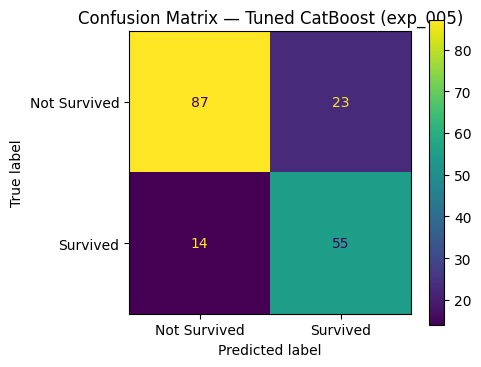

In [7]:
best_tuned = grid_search.best_estimator_
y_pred = best_tuned.predict(X_test)
y_prob = best_tuned.predict_proba(X_test)[:, 1]

print('--- Stage 2 (GridSearch) hold-out results ---')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(best_tuned, X_test, y_test,
                                      display_labels=['Not Survived', 'Survived'], ax=ax)
plt.title('Confusion Matrix — Tuned CatBoost (exp_005)')
plt.tight_layout()
plt.show()

## 6. Tuning Progression Summary

In [8]:
# Compare default → stage 1 → stage 2
r1 = classification_report(y_test, y_pred_r, output_dict=True)
r2 = classification_report(y_test, y_pred,   output_dict=True)

tuning_summary = pd.DataFrame([
    {'Stage': 'Default (exp_004)',   'CV F1': '-',    'Hold-out AUC': 0.8506, 'F1 (Survived)': 0.783, 'Recall (Survived)': 0.812, 'Accuracy': 0.827},
    {'Stage': 'RandomizedSearch',    'CV F1': round(random_search.best_score_, 4),
     'Hold-out AUC': round(roc_auc_score(y_test, y_prob_r), 4),
     'F1 (Survived)': round(r1['1']['f1-score'], 3),
     'Recall (Survived)': round(r1['1']['recall'], 3),
     'Accuracy': round(r1['accuracy'], 3)},
    {'Stage': 'GridSearch (final)',  'CV F1': round(grid_search.best_score_, 4),
     'Hold-out AUC': round(roc_auc_score(y_test, y_prob), 4),
     'F1 (Survived)': round(r2['1']['f1-score'], 3),
     'Recall (Survived)': round(r2['1']['recall'], 3),
     'Accuracy': round(r2['accuracy'], 3)},
]).set_index('Stage')

print('Tuning progression:')
tuning_summary

Tuning progression:


,CV F1,Hold-out AUC,F1 (Survived),Recall (Survived),Accuracy
Stage,,,,,
Default (exp_004),-,0.8506,0.783,0.812,0.827
RandomizedSearch,0.7902,0.8414,0.753,0.797,0.799
GridSearch (final),0.7916,0.8428,0.748,0.797,0.793


## 7. Full Experiment Comparison

In [9]:
summary = pd.DataFrame([
    {'Experiment': 'exp_001 Baseline RF',          'CV AUC': 0.8741, 'Hold-out AUC': 0.8282, 'F1 (Survived)': 0.71, 'Recall (Survived)': 0.68, 'Accuracy': 0.79},
    {'Experiment': 'exp_002 Undersample RF',        'CV AUC': 0.8724, 'Hold-out AUC': 0.8237, 'F1 (Survived)': 0.69, 'Recall (Survived)': 0.77, 'Accuracy': 0.74},
    {'Experiment': 'exp_003 FE + Undersample RF',   'CV AUC': 0.8727, 'Hold-out AUC': 0.8216, 'F1 (Survived)': 0.73, 'Recall (Survived)': 0.81, 'Accuracy': 0.77},
    {'Experiment': 'exp_004 CatBoost (default)',    'CV AUC': 0.8909, 'Hold-out AUC': 0.8506, 'F1 (Survived)': 0.783, 'Recall (Survived)': 0.812, 'Accuracy': 0.827},
    {'Experiment': 'exp_005 CatBoost (tuned)',      'CV AUC': round(grid_search.best_score_, 4),
     'Hold-out AUC': round(roc_auc_score(y_test, y_prob), 4),
     'F1 (Survived)': round(r2['1']['f1-score'], 3),
     'Recall (Survived)': round(r2['1']['recall'], 3),
     'Accuracy': round(r2['accuracy'], 3)},
]).set_index('Experiment')

summary

,CV AUC,Hold-out AUC,F1 (Survived),Recall (Survived),Accuracy
Experiment,,,,,
exp_001 Baseline RF,0.8741,0.8282,0.710,0.680,0.790
exp_002 Undersample RF,0.8724,0.8237,0.690,0.770,0.740
exp_003 FE + Undersample RF,0.8727,0.8216,0.730,0.810,0.770
exp_004 CatBoost (default),0.8909,0.8506,0.783,0.812,0.827
exp_005 CatBoost (tuned),0.7916,0.8428,0.748,0.797,0.793
